# E4 — Análisis Exploratorio: Región Pampeana

**Dataset:** `dataset/smn_historico.csv` (estadísticas climatológicas normales SMN, 1991–2020).
Cada fila es un par **estación × mes** (12 filas por estación).

**Región elegida:** Pampeana → `BUENOS AIRES, CORDOBA, SANTA FE, ENTRE RIOS, LA PAMPA, CAPITAL FEDERAL`

> ⚠️ **Dos cuidados con estos datos:**
> 1. `temp`, `prec_mm` y otras columnas vienen como **texto** con el centinela `S/D` (sin dato) → hay que
>    convertirlas con `pd.to_numeric(..., errors='coerce')`, si no `.mean()` falla o da resultados erróneos.
> 2. Las provincias están escritas en **MAYÚSCULAS y SIN TILDES** (`CORDOBA`, `ENTRE RIOS`), distinto de
>    cómo aparecen en el enunciado (`CÓRDOBA`, `ENTRE RíOS`) → se normaliza el texto antes de filtrar.

## 0. Configuración

In [2]:
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Carga de datos

In [3]:
# El notebook vive en E4/ y el dataset en E4/dataset/
RUTA = Path("dataset/smn_historico.csv")
if not RUTA.exists():
    RUTA = Path("E4/dataset/smn_historico.csv")

df = pd.read_csv(RUTA)

print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")
print(f"Estaciones únicas (todo el país): {df['estacion'].nunique()}")
df.head()

Filas: 1176  |  Columnas: 16
Estaciones únicas (todo el país): 98


,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9


In [4]:
# Tipos de dato originales: ojo que las variables numéricas llegan como 'object'/'str'
df.dtypes.to_frame("dtype_original")

,dtype_original
estacion,str
provincia,str
altura,float64
numero,float64
NroOACI,str
LAT_decimal,float64
LON_decimal,float64
mes_txt,str
prec_sup_1mm,str
humedad,str


## 2. Limpieza

### 2.1 Centinela `S/D` → `NaN` y conversión a numérico

In [5]:
COLS_NUMERICAS = [
    "prec_sup_1mm", "humedad", "nubosidad", "prec_mm",
    "temp", "temp_max", "temp_min", "viento",
]

# Cuántos 'S/D' hay por columna antes de convertir
sd_por_columna = {c: (df[c].astype("string").str.strip() == "S/D").sum() for c in COLS_NUMERICAS}
print("Valores 'S/D' por columna:")
for c, n in sd_por_columna.items():
    print(f"  {c:<14} {n}")

# Conversión: 'S/D' y cualquier texto no numérico pasan a NaN
for c in COLS_NUMERICAS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[COLS_NUMERICAS].dtypes.to_frame("dtype_convertido")

Valores 'S/D' por columna:
  prec_sup_1mm   115
  humedad        66
  nubosidad      10
  prec_mm        115
  temp           9
  temp_max       18
  temp_min       52
  viento         468


,dtype_convertido
prec_sup_1mm,float64
humedad,float64
nubosidad,float64
prec_mm,float64
temp,float64
temp_max,float64
temp_min,float64
viento,float64


### 2.2 Normalización de los textos de provincia

Se pasa a mayúsculas, se quitan espacios sobrantes y se eliminan las tildes, para que el filtro
funcione sin importar cómo esté escrita la provincia en el enunciado o en el dataset.

In [6]:
def normalizar(texto):
    """Mayúsculas, sin tildes y sin espacios sobrantes. Devuelve None si el valor es nulo."""
    if pd.isna(texto):
        return None
    txt = unicodedata.normalize("NFKD", str(texto))
    txt = "".join(ch for ch in txt if not unicodedata.combining(ch))  # saca las tildes
    return " ".join(txt.upper().split())


df["provincia_norm"] = df["provincia"].apply(normalizar)
df["estacion"] = df["estacion"].str.strip()

print("Provincias tal como figuran en el dataset:")
print(sorted(p for p in df["provincia_norm"].dropna().unique()))

Provincias tal como figuran en el dataset:
['ANTARTIDA', 'BUENOS AIRES', 'CAPITAL FEDERAL', 'CATAMARCA', 'CHACO', 'CHUBUT', 'CORDOBA', 'CORRIENTES', 'ENTRE RIOS', 'FORMOSA', 'JUJUY', 'LA PAMPA', 'LA RIOJA', 'MENDOZA', 'MISIONES', 'NEUQUEN', 'RIO NEGRO', 'SALTA', 'SAN JUAN', 'SAN LUIS', 'SANTA CRUZ', 'SANTA FE', 'SANTIAGO DEL ES', 'TIERRA DEL FUEG', 'TUCUMAN']


### 2.3 Estaciones sin provincia asignada

Hay filas con `provincia` nula. Conviene mirarlas antes de filtrar, porque si pertenecen a la región
elegida cambian el conteo de estaciones.

In [7]:
sin_provincia = df[df["provincia_norm"].isna()]
print(f"Filas sin provincia: {len(sin_provincia)}  "
      f"({sin_provincia['estacion'].nunique()} estaciones)")
sin_provincia[["estacion", "provincia", "altura", "temp", "prec_mm"]].groupby("estacion").agg(
    filas=("temp", "size"), altura=("altura", "first"), temp_media=("temp", "mean")
)

Filas sin provincia: 24  (2 estaciones)


,filas,altura,temp_media
estacion,,,
CORONEL PRINGLES AERO,12,NaN,13.65
EL TREBOL,12,NaN,17.25


## 3. Filtro de la región

Se define el mapa completo de regiones (normalizado) y se filtra **únicamente** la Pampeana.
Para analizar otra región alcanza con cambiar `REGION_ELEGIDA`.

In [8]:
REGIONES = {
    "Pampeana": ["BUENOS AIRES", "CORDOBA", "SANTA FE", "ENTRE RIOS", "LA PAMPA", "CAPITAL FEDERAL"],
    "Cuyo":     ["MENDOZA", "SAN JUAN", "SAN LUIS", "LA RIOJA"],
    "NOA":      ["JUJUY", "SALTA", "TUCUMAN", "CATAMARCA", "SANTIAGO DEL ESTERO"],
    "NEA":      ["MISIONES", "CORRIENTES", "FORMOSA", "CHACO"],
    "Patagonia": ["NEUQUEN", "RIO NEGRO", "CHUBUT", "SANTA CRUZ", "TIERRA DEL FUEGO", "ANTARTIDA"],
}
# Se normalizan también las claves de la región por las dudas (tildes del enunciado)
REGIONES = {r: [normalizar(p) for p in provs] for r, provs in REGIONES.items()}

REGION_ELEGIDA = "Pampeana"
PROVINCIAS = REGIONES[REGION_ELEGIDA]

# Chequeo: ¿todas las provincias de la región existen tal cual en el dataset?
en_dataset = set(df["provincia_norm"].dropna().unique())
for p in PROVINCIAS:
    print(f"  {'OK ' if p in en_dataset else '❌ NO ENCONTRADA'} {p}")

  OK  BUENOS AIRES
  OK  CORDOBA
  OK  SANTA FE
  OK  ENTRE RIOS
  OK  LA PAMPA
  OK  CAPITAL FEDERAL


In [9]:
reg = df[df["provincia_norm"].isin(PROVINCIAS)].copy()

print(f"Región: {REGION_ELEGIDA}")
print(f"Filas (estación × mes): {len(reg)}")
print(f"Estaciones: {reg['estacion'].nunique()}")
reg.head()

Región: Pampeana
Filas (estación × mes): 480
Estaciones: 40


,estacion,provincia,altura,numero,NroOACI,LAT_decimal,LON_decimal,mes_txt,prec_sup_1mm,humedad,nubosidad,prec_mm,temp,temp_max,temp_min,viento,provincia_norm
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Ene,6.7,67.0,3.1,117.5,24.5,28.4,20.8,16.8,CAPITAL FEDERAL
1,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Feb,6.0,69.8,3.2,112.3,23.7,27.3,20.2,15.8,CAPITAL FEDERAL
2,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Mar,5.9,71.3,3.1,111.8,22.0,25.5,18.8,14.9,CAPITAL FEDERAL
3,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,Abr,6.6,73.6,3.5,108.3,18.5,22.0,15.3,13.9,CAPITAL FEDERAL
4,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,87582.0,SABE,-34.55,-58.416667,May,5.0,76.4,4.0,83.3,15.2,18.4,12.3,12.9,CAPITAL FEDERAL


### 3.1 Tabla a nivel estación

Varias preguntas (cantidad de estaciones, altura media, correlación altura-temperatura) se responden
**por estación**, no por fila. Se arma una tabla con una fila por estación.

In [10]:
estaciones = (
    reg.groupby(["estacion", "provincia_norm"], as_index=False)
       .agg(
           altura=("altura", "first"),
           temp_media=("temp", "mean"),
           prec_media=("prec_mm", "mean"),
           prec_anual=("prec_mm", "sum"),
       )
       .rename(columns={"provincia_norm": "provincia"})
)

print(f"Estaciones en la región: {len(estaciones)}")
estaciones.sort_values("temp_media", ascending=False).head(10)

Estaciones en la región: 40


,estacion,provincia,altura,temp_media,prec_media,prec_anual
29,RECONQUISTA AERO,SANTA FE,53.0,20.233333,102.150000,1225.8
5,CERES AERO,SANTA FE,88.0,19.075000,78.600000,943.2
6,CONCORDIA AERO,ENTRE RIOS,37.0,18.950000,122.333333,1468.0
34,SAUCE VIEJO AERO,SANTA FE,18.0,18.925000,89.650000,1075.8
8,CORDOBA OBSERVATORIO,CORDOBA,425.0,18.383333,67.966667,815.6
39,VILLA DOLORES AERO,CORDOBA,569.0,18.358333,53.391667,640.7
24,PARANA AERO,ENTRE RIOS,78.0,18.333333,96.233333,1154.8
4,BUENOS AIRES OBSERVATORIO,CAPITAL FEDERAL,25.0,18.083333,104.800000,1257.6
0,AEROPARQUE AERO,CAPITAL FEDERAL,6.0,18.050000,92.241667,1106.9
14,GUALEGUAYCHU AERO,ENTRE RIOS,23.0,17.925000,101.500000,1218.0


---
## Pregunta 1 — ¿Cuántas estaciones meteorológicas hay en la región?

In [11]:
n_estaciones = reg["estacion"].nunique()
print(f"Estaciones en la región {REGION_ELEGIDA}: {n_estaciones}")

print("\nDesglose por provincia:")
print(reg.groupby("provincia_norm")["estacion"].nunique().sort_values(ascending=False).to_string())

# Opciones del enunciado
for etiqueta, cumple in [
    ("<= 10",           n_estaciones <= 10),
    ("entre 11 y 20",   11 <= n_estaciones <= 20),
    ("entre 21 y 30",   21 <= n_estaciones <= 30),
    ("entre 31 y 40",   31 <= n_estaciones <= 40),
    (">= 40",           n_estaciones >= 40),
]:
    print(f"  {'>>>' if cumple else '   '} {etiqueta}")

Estaciones en la región Pampeana: 40

Desglose por provincia:
provincia_norm
BUENOS AIRES       20
CORDOBA             8
SANTA FE            5
ENTRE RIOS          3
CAPITAL FEDERAL     2
LA PAMPA            2
      <= 10
      entre 11 y 20
      entre 21 y 30
  >>> entre 31 y 40
  >>> >= 40


---
## Pregunta 2 — ¿Cuál es la altura media de las estaciones en la región?

In [12]:
# Se promedia una altura por estación (no por fila, que repetiría cada estación 12 veces)
altura_media = estaciones["altura"].mean()

print(f"Altura media (por estación): {altura_media:.2f} m")
print(f"Estaciones con altura informada: {estaciones['altura'].notna().sum()} de {len(estaciones)}")
print(f"\nMínima: {estaciones['altura'].min():.1f} m   |   Máxima: {estaciones['altura'].max():.1f} m")
print(f"Mediana: {estaciones['altura'].median():.1f} m")

for etiqueta, cumple in [
    ("<100 m",              altura_media < 100),
    ("entre 101 m y 300 m", 100 <= altura_media <= 300),
    ("entre 301 m y 500 m", 300 < altura_media <= 500),
    ("entre 501 m y 1000 m",500 < altura_media <= 1000),
    (">1000 m",             altura_media > 1000),
]:
    print(f"  {'>>>' if cumple else '   '} {etiqueta}")

Altura media (por estación): 134.55 m
Estaciones con altura informada: 40 de 40

Mínima: 5.0 m   |   Máxima: 569.0 m
Mediana: 85.0 m
      <100 m
  >>> entre 101 m y 300 m
      entre 301 m y 500 m
      entre 501 m y 1000 m
      >1000 m


---
## Pregunta 3 — ¿Cuál es la temperatura media (`temp`) de la región?

In [13]:
temp_media = reg["temp"].mean()

print(f"Temperatura media de la región: {temp_media:.2f} °C")
print(f"Registros válidos de temp: {reg['temp'].notna().sum()} de {len(reg)}")
print(f"\n{reg['temp'].describe().to_string()}")

for etiqueta, cumple in [
    ("<10 °C",                 temp_media < 10),
    ("entre 10.1 °C y 15 °C",  10 <= temp_media <= 15),
    ("entre 15.1 °C y 20 °C",  15 < temp_media <= 20),
    ("entre 20.1 °C y 25 °C",  20 < temp_media <= 25),
    (">25 °C",                 temp_media > 25),
]:
    print(f"  {'>>>' if cumple else '   '} {etiqueta}")

Temperatura media de la región: 16.55 °C
Registros válidos de temp: 477 de 480

count    477.000000
mean      16.546541
std        5.191486
min        6.100000
25%       12.100000
50%       16.700000
75%       21.200000
max       26.400000
      <10 °C
      entre 10.1 °C y 15 °C
  >>> entre 15.1 °C y 20 °C
      entre 20.1 °C y 25 °C
      >25 °C


---
## Pregunta 4 — ¿Cuál es el desvío estándar de la temperatura (`temp`) en la región?

In [14]:
desvio = reg["temp"].std()          # muestral (ddof=1), el default de pandas

print(f"Desvío estándar de temp: {desvio:.2f} °C")
print(f"(poblacional, ddof=0: {reg['temp'].std(ddof=0):.2f} °C)")

for etiqueta, cumple in [
    ("menor que 5 °C",   desvio < 5),
    ("entre 5 °C y 10 °C", 5 <= desvio <= 10),
    ("mayor que 10 °C",  desvio > 10),
]:
    print(f"  {'>>>' if cumple else '   '} {etiqueta}")

Desvío estándar de temp: 5.19 °C
(poblacional, ddof=0: 5.19 °C)
      menor que 5 °C
  >>> entre 5 °C y 10 °C
      mayor que 10 °C


In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(reg["temp"].dropna(), bins=25, kde=True, color="steelblue")
plt.axvline(temp_media, color="red", ls="--", label=f"media = {temp_media:.1f} °C")
plt.axvline(temp_media - desvio, color="orange", ls=":", label=f"± 1 desvío ({desvio:.1f} °C)")
plt.axvline(temp_media + desvio, color="orange", ls=":")
plt.title(f"Distribución de la temperatura — Región {REGION_ELEGIDA}")
plt.xlabel("temp (°C)"); plt.legend(); plt.tight_layout(); plt.show()

---
## Pregunta 5 — ¿En qué mes se registra la mayor precipitación media (`prec_mm`)?

In [15]:
ORDEN_MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
               "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
NOMBRE_MES = {
    "Ene": "Enero", "Feb": "Febrero", "Mar": "Marzo", "Abr": "Abril",
    "May": "Mayo", "Jun": "Junio", "Jul": "Julio", "Ago": "Agosto",
    "Sep": "Septiembre", "Oct": "Octubre", "Nov": "Noviembre", "Dic": "Diciembre",
}

prec_por_mes = (
    reg.groupby("mes_txt")["prec_mm"]
       .agg(media="mean", n="count")
       .reindex(ORDEN_MESES)
)
prec_por_mes["mes"] = [NOMBRE_MES[m] for m in prec_por_mes.index]

mes_max = prec_por_mes["media"].idxmax()
print(f"Mes con mayor precipitación media: {NOMBRE_MES[mes_max]} "
      f"({prec_por_mes.loc[mes_max, 'media']:.2f} mm)\n")
print(prec_por_mes[["mes", "media", "n"]].to_string())

Mes con mayor precipitación media: Marzo (113.37 mm)

                mes       media   n
mes_txt                            
Ene           Enero  112.500000  40
Feb         Febrero  112.679487  39
Mar           Marzo  113.372500  40
Abr           Abril   97.012500  40
May            Mayo   55.330000  40
Jun           Junio   35.870000  40
Jul           Julio   36.089474  38
Ago          Agosto   40.867500  40
Sep      Septiembre   55.138462  39
Oct         Octubre   99.510000  40
Nov       Noviembre  103.095000  40
Dic       Diciembre  111.058974  39


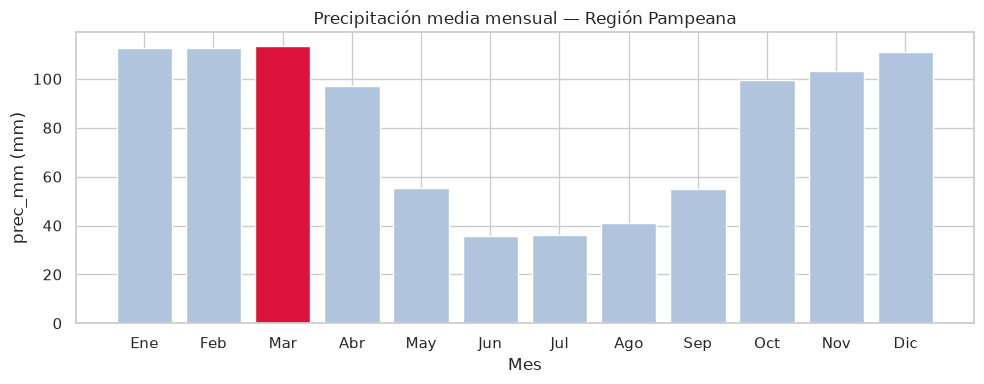

In [16]:
plt.figure(figsize=(10, 4))
colores = ["crimson" if m == mes_max else "lightsteelblue" for m in prec_por_mes.index]
plt.bar(prec_por_mes.index, prec_por_mes["media"], color=colores)
plt.title(f"Precipitación media mensual — Región {REGION_ELEGIDA}")
plt.ylabel("prec_mm (mm)"); plt.xlabel("Mes"); plt.tight_layout(); plt.show()

---
## Pregunta 6 — ¿Qué provincia tiene la mayor temperatura media?

In [17]:
temp_por_provincia = (
    reg.groupby("provincia_norm")["temp"]
       .agg(temp_media="mean", desvio="std", n_registros="count")
       .sort_values("temp_media", ascending=False)
)
temp_por_provincia["n_estaciones"] = reg.groupby("provincia_norm")["estacion"].nunique()

print(f"Provincia más cálida: {temp_por_provincia.index[0]} "
      f"({temp_por_provincia.iloc[0]['temp_media']:.2f} °C)\n")
temp_por_provincia

Provincia más cálida: SANTA FE (18.48 °C)



,temp_media,desvio,n_registros,n_estaciones
provincia_norm,,,,
SANTA FE,18.480000,4.945767,60,5
ENTRE RIOS,18.402778,4.744951,36,3
CAPITAL FEDERAL,18.066667,4.726490,24,2
CORDOBA,17.327083,5.012458,96,8
LA PAMPA,15.962500,5.664290,24,2
BUENOS AIRES,15.364135,5.107872,237,20


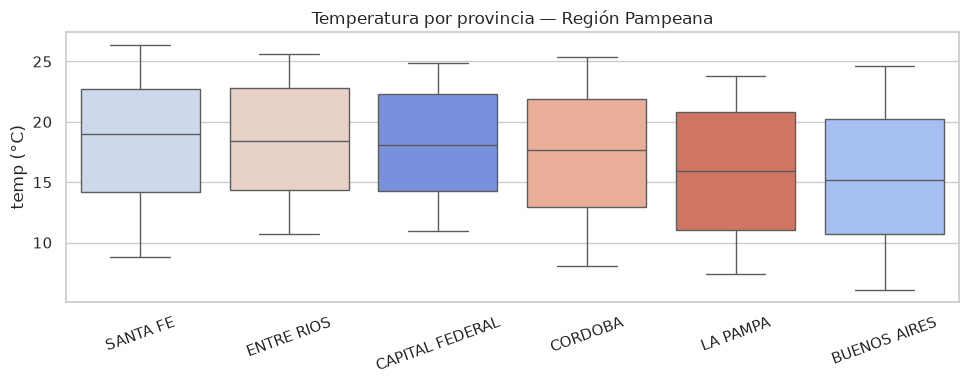

In [18]:
plt.figure(figsize=(10, 4))
orden = temp_por_provincia.index
sns.boxplot(data=reg, x="provincia_norm", y="temp", order=orden, palette="coolwarm", hue="provincia_norm", legend=False)
plt.title(f"Temperatura por provincia — Región {REGION_ELEGIDA}")
plt.xlabel(""); plt.ylabel("temp (°C)"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

---
## Pregunta 7 — ¿En qué variables aparecen valores atípicos (outliers)?

Se usa el criterio del rango intercuartílico (IQR): es outlier todo valor fuera de
$[\,Q_1 - 1.5\cdot IQR,\ Q_3 + 1.5\cdot IQR\,]$.

In [19]:
def detectar_outliers(serie, nombre):
    s = serie.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fuera = s[(s < lim_inf) | (s > lim_sup)]

    print(f"\n--- {nombre} ---")
    print(f"  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}")
    print(f"  Límites: [{lim_inf:.2f} , {lim_sup:.2f}]")
    print(f"  Outliers: {len(fuera)} de {len(s)} ({100 * len(fuera) / len(s):.1f} %)")
    if len(fuera):
        print(f"  Rango de los outliers: {fuera.min():.2f} a {fuera.max():.2f}")
    return fuera


out_temp = detectar_outliers(reg["temp"], "temperatura (temp)")
out_prec = detectar_outliers(reg["prec_mm"], "precipitación (prec_mm)")

print("\n" + "=" * 55)
print(f"¿Outliers en temperatura?   {'SÍ' if len(out_temp) else 'NO'}")
print(f"¿Outliers en precipitación? {'SÍ' if len(out_prec) else 'NO'}")


--- temperatura (temp) ---
  Q1=12.10  Q3=21.20  IQR=9.10
  Límites: [-1.55 , 34.85]
  Outliers: 0 de 477 (0.0 %)

--- precipitación (prec_mm) ---
  Q1=52.85  Q3=111.40  IQR=58.55
  Límites: [-34.98 , 199.23]
  Outliers: 0 de 475 (0.0 %)

¿Outliers en temperatura?   NO
¿Outliers en precipitación? NO


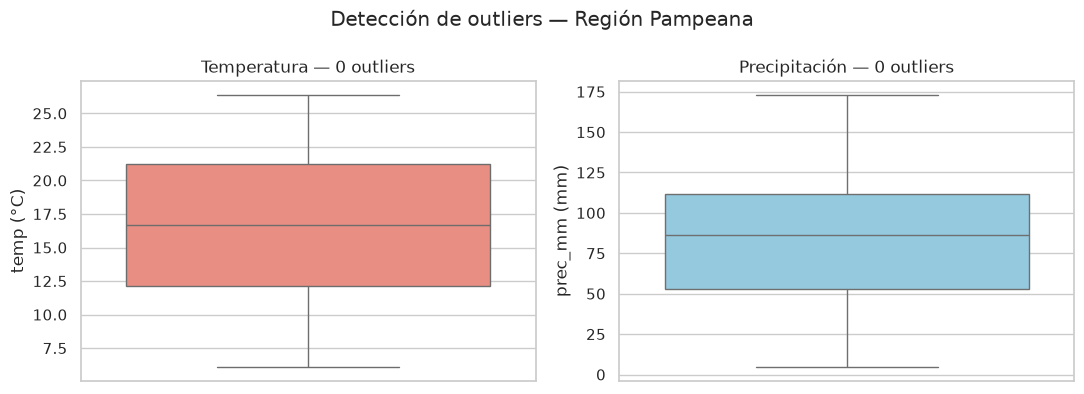

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=reg["temp"], ax=axes[0], color="salmon")
axes[0].set_title(f"Temperatura — {len(out_temp)} outliers"); axes[0].set_ylabel("temp (°C)")
sns.boxplot(y=reg["prec_mm"], ax=axes[1], color="skyblue")
axes[1].set_title(f"Precipitación — {len(out_prec)} outliers"); axes[1].set_ylabel("prec_mm (mm)")
plt.suptitle(f"Detección de outliers — Región {REGION_ELEGIDA}")
plt.tight_layout(); plt.show()

In [22]:
# Qué estaciones/meses son los outliers, para darle contexto al resultado
if len(out_prec):
    print("Registros con precipitación atípica:")
    print(reg.loc[out_prec.index, ["estacion", "provincia_norm", "mes_txt", "prec_mm"]]
             .sort_values("prec_mm", ascending=False).to_string(index=False))
if len(out_temp):
    print("\nRegistros con temperatura atípica:")
    print(reg.loc[out_temp.index, ["estacion", "provincia_norm", "mes_txt", "temp"]]
             .sort_values("temp", ascending=False).to_string(index=False))

---
## Pregunta 8 — Correlación de Spearman entre altura y temperatura media

Se calcula **a nivel estación**: una altura y una temperatura media por estación.
Spearman mide asociación *monótona* por rangos, por eso no requiere que la relación sea lineal.

In [23]:
datos_corr = estaciones[["estacion", "provincia", "altura", "temp_media"]].dropna()

rho, p_valor = stats.spearmanr(datos_corr["altura"], datos_corr["temp_media"])

print(f"Estaciones usadas: {len(datos_corr)} (de {len(estaciones)}; se descartan las de altura nula)")
print(f"\nCoeficiente de Spearman (rho): {rho:.4f}")
print(f"p-valor: {p_valor:.6f}  ->  {'significativo' if p_valor < 0.05 else 'NO significativo'} (alfa = 0.05)")

fuerza = ("nula" if abs(rho) < 0.1 else "débil" if abs(rho) < 0.3
          else "moderada" if abs(rho) < 0.5 else "fuerte" if abs(rho) < 0.7 else "muy fuerte")
sentido = "inversa (a mayor altura, menor temperatura)" if rho < 0 else "directa (crecen juntas)"
print(f"\nAsociación {fuerza}, de sentido {sentido if abs(rho) >= 0.1 else '—'}")

# Comparación con Pearson, sólo como referencia
r_pearson, _ = stats.pearsonr(datos_corr["altura"], datos_corr["temp_media"])
print(f"\n(Pearson, a modo de comparación: {r_pearson:.4f})")

Estaciones usadas: 40 (de 40; se descartan las de altura nula)

Coeficiente de Spearman (rho): -0.1745
p-valor: 0.281488  ->  NO significativo (alfa = 0.05)

Asociación débil, de sentido inversa (a mayor altura, menor temperatura)

(Pearson, a modo de comparación: -0.0218)


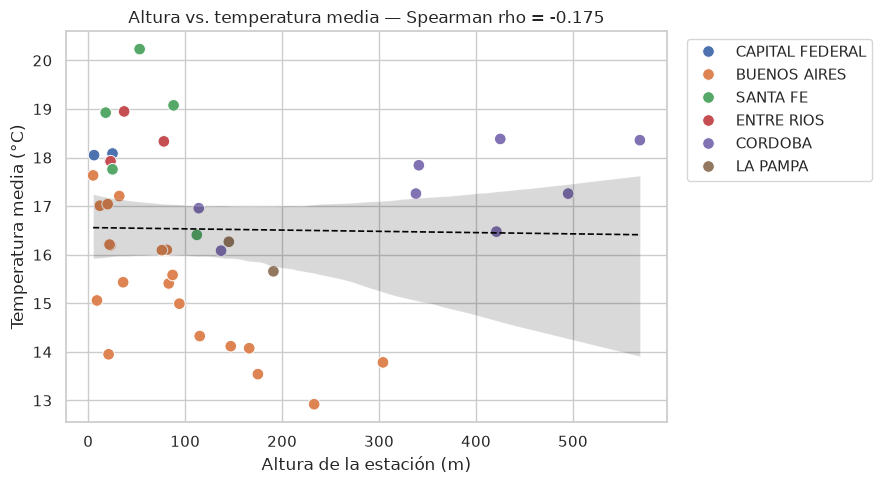

In [24]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=datos_corr, x="altura", y="temp_media", hue="provincia", s=70)
sns.regplot(data=datos_corr, x="altura", y="temp_media", scatter=False,
            color="black", line_kws={"ls": "--", "lw": 1.2})
plt.title(f"Altura vs. temperatura media — Spearman rho = {rho:.3f}")
plt.xlabel("Altura de la estación (m)"); plt.ylabel("Temperatura media (°C)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

---
## Pregunta 9 — Eta cuadrado entre provincia y precipitación

$\eta^2$ mide qué proporción de la variabilidad de una variable **numérica** (precipitación) se explica
por una variable **categórica** (provincia):

$$\eta^2 = \frac{SS_{entre}}{SS_{total}}$$

Interpretación habitual: `< 0.06` débil · `0.06 – 0.14` moderada · `> 0.14` fuerte.

In [25]:
def eta_cuadrado(datos, categoria, numerica):
    """Proporción de la varianza de `numerica` explicada por los grupos de `categoria`."""
    d = datos[[categoria, numerica]].dropna()
    media_general = d[numerica].mean()

    ss_total = ((d[numerica] - media_general) ** 2).sum()
    ss_entre = sum(
        len(grupo) * (grupo.mean() - media_general) ** 2
        for _, grupo in d.groupby(categoria)[numerica]
    )
    return ss_entre / ss_total, ss_entre, ss_total


eta2, ss_entre, ss_total = eta_cuadrado(reg, "provincia_norm", "prec_mm")

print(f"SS entre grupos: {ss_entre:,.2f}")
print(f"SS total:        {ss_total:,.2f}")
print(f"\neta cuadrado = {eta2:.4f}  ->  la provincia explica el {eta2 * 100:.2f} % "
      f"de la variabilidad de la precipitación")

interpretacion = ("débil" if eta2 < 0.06 else "moderada" if eta2 < 0.14 else "fuerte")
print(f"Asociación: {interpretacion.upper()}")

# ANOVA de una vía, como chequeo complementario
grupos = [g["prec_mm"].dropna().values for _, g in reg.groupby("provincia_norm")]
f_stat, p_anova = stats.f_oneway(*grupos)
print(f"\n(ANOVA: F = {f_stat:.3f}, p = {p_anova:.6f})")

SS entre grupos: 53,218.36
SS total:        679,967.30

eta cuadrado = 0.0783  ->  la provincia explica el 7.83 % de la variabilidad de la precipitación
Asociación: MODERADA

(ANOVA: F = 7.965, p = 0.000000)


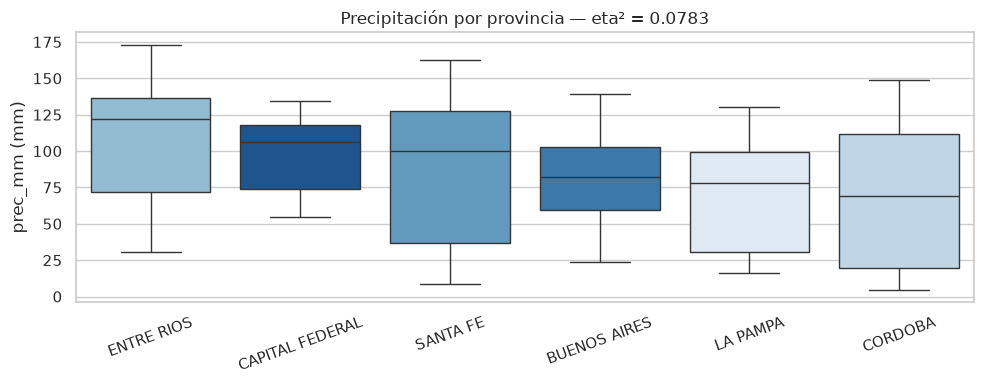

In [26]:
plt.figure(figsize=(10, 4))
orden_prec = reg.groupby("provincia_norm")["prec_mm"].mean().sort_values(ascending=False).index
sns.boxplot(data=reg, x="provincia_norm", y="prec_mm", order=orden_prec,
            palette="Blues_r", hue="provincia_norm", legend=False)
plt.title(f"Precipitación por provincia — eta² = {eta2:.4f}")
plt.xlabel(""); plt.ylabel("prec_mm (mm)"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

---
## Resumen de resultados

In [27]:
resumen = pd.DataFrame([
    ("1. Cantidad de estaciones",               f"{n_estaciones}"),
    ("2. Altura media",                         f"{altura_media:.2f} m"),
    ("3. Temperatura media",                    f"{temp_media:.2f} °C"),
    ("4. Desvío estándar de temp",              f"{desvio:.2f} °C"),
    ("5. Mes de mayor precipitación media",     f"{NOMBRE_MES[mes_max]} ({prec_por_mes.loc[mes_max, 'media']:.2f} mm)"),
    ("6. Provincia más cálida",                 f"{temp_por_provincia.index[0]} ({temp_por_provincia.iloc[0]['temp_media']:.2f} °C)"),
    ("7. Outliers en temperatura",              f"{len(out_temp)}"),
    ("7. Outliers en precipitación",            f"{len(out_prec)}"),
    ("8. Spearman altura vs temp",              f"rho = {rho:.4f} (p = {p_valor:.4g})"),
    ("9. Eta cuadrado provincia vs prec_mm",    f"{eta2:.4f} ({interpretacion})"),
], columns=["Pregunta", "Resultado"])

print(f"REGIÓN: {REGION_ELEGIDA}  —  provincias: {', '.join(PROVINCIAS)}\n")
resumen.style.hide(axis="index")

REGIÓN: Pampeana  —  provincias: BUENOS AIRES, CORDOBA, SANTA FE, ENTRE RIOS, LA PAMPA, CAPITAL FEDERAL



Pregunta,Resultado
1. Cantidad de estaciones,40
2. Altura media,134.55 m
3. Temperatura media,16.55 °C
4. Desvío estándar de temp,5.19 °C
5. Mes de mayor precipitación media,Marzo (113.37 mm)
6. Provincia más cálida,SANTA FE (18.48 °C)
7. Outliers en temperatura,0
7. Outliers en precipitación,0
8. Spearman altura vs temp,rho = -0.1745 (p = 0.2815)
9. Eta cuadrado provincia vs prec_mm,0.0783 (moderada)
